# Применение классификаторов

Лабораторная работа № 3 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Текста задания в СДО нет, поэтому беру стандартное содержание такой работы:
табличный набор данных, пять классификаторов разной природы, сравнение по accuracy, precision,
recall, F1 и ROC-AUC, матрицы ошибок и вывод, какой классификатор лучше и почему.
Набор данных другой, не тот, что в курсовой.

**Данные.** Wine Quality из репозитория UCI: результаты лабораторных измерений вина
(кислотность, сахар, спирт и другие) и оценка дегустаторов от 0 до 10. Беру красное и белое
вино вместе, 6497 записей, 11 числовых признаков.

**Задача.** Оценка дегустаторов приводится к бинарной: вино хорошее, если оценка не ниже 6.
Предсказать, понравится вино дегустаторам, по одним лабораторным измерениям.

**Классификаторы:** логистическая регрессия, k ближайших соседей, дерево решений,
случайный лес, метод опорных векторов.

## 0. Библиотеки и настройки

In [1]:
import os
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

## 1. Загрузка данных

Файлы скачиваются с сайта UCI при первом запуске и сохраняются в `data/`.
Красное и белое вино лежат в отдельных файлах, объединяю их и добавляю признак `is_red`.

In [2]:
os.makedirs('data', exist_ok=True)
BASE = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/'

frames = []
for kind in ['red', 'white']:
    path = f'data/winequality-{kind}.csv'
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE + f'winequality-{kind}.csv', path)
    part = pd.read_csv(path, sep=';')
    part['is_red'] = int(kind == 'red')
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
print('Размер таблицы:', df.shape)
print('Красного вина:', int(df['is_red'].sum()), 'белого:', int((1 - df['is_red']).sum()))
df.head(3)

Размер таблицы: (6497, 13)
Красного вина: 1599 белого: 4898


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1


In [3]:
df.info()
print('\nПропуски:', int(df.isna().sum().sum()))
print('Полных дубликатов:', int(df.duplicated().sum()))
df.describe().T.round(2)

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  is_red                6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB

Пропуски: 0
Полных дубликатов: 1177


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.22,1.30,3.80,6.40,7.00,7.70,15.90
volatile acidity,6497.0,0.34,0.16,0.08,0.23,0.29,0.40,1.58
citric acid,6497.0,0.32,0.15,0.00,0.25,0.31,0.39,1.66
residual sugar,6497.0,5.44,4.76,0.60,1.80,3.00,8.10,65.80
chlorides,6497.0,0.06,0.04,0.01,0.04,0.05,0.06,0.61
free sulfur dioxide,6497.0,30.53,17.75,1.00,17.00,29.00,41.00,289.00
total sulfur dioxide,6497.0,115.74,56.52,6.00,77.00,118.00,156.00,440.00
density,6497.0,0.99,0.00,0.99,0.99,0.99,1.00,1.04
pH,6497.0,3.22,0.16,2.72,3.11,3.21,3.32,4.01
sulphates,6497.0,0.53,0.15,0.22,0.43,0.51,0.60,2.00


Дубликаты в наборе есть: разные бутылки одного вина дают одинаковые измерения. Удалять их не буду,
это не ошибки ввода, а повторяющиеся результаты лаборатории.

## 2. Целевая переменная и описательный анализ

Оценка дегустаторов принимает значения от 3 до 9, и распределена очень неравномерно.
Перевожу её в бинарную: хорошее вино, если оценка не ниже 6.

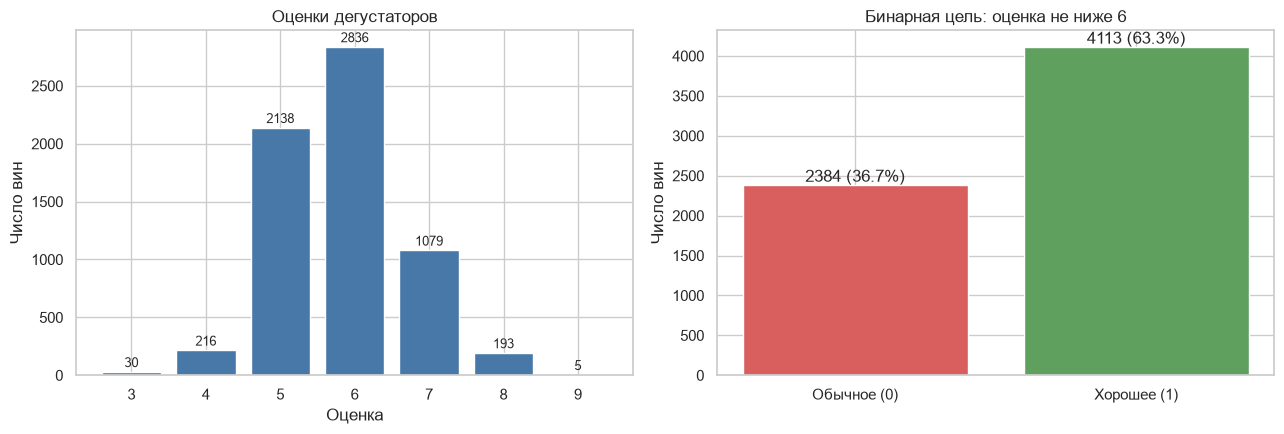

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vc = df['quality'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color='#4878a8')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 40, str(v), ha='center', fontsize=9)
axes[0].set_title('Оценки дегустаторов')
axes[0].set_xlabel('Оценка')
axes[0].set_ylabel('Число вин')

df['target'] = (df['quality'] >= 6).astype(int)
tc = df['target'].value_counts().sort_index()
axes[1].bar(['Обычное (0)', 'Хорошее (1)'], tc.values, color=['#d95f5f', '#5fa05f'])
for i, v in enumerate(tc.values):
    axes[1].text(i, v + 40, f'{v} ({v / len(df):.1%})', ha='center')
axes[1].set_title('Бинарная цель: оценка не ниже 6')
axes[1].set_ylabel('Число вин')
fig.tight_layout()
save_fig('01_target.png')
plt.show()

**Рисунок 1 — Оценки дегустаторов и бинарная целевая переменная**

Оценок 5 и 6 больше всего (2138 и 2836 из 6497), крайние оценки редкие: 3 балла у 30 вин, 9 баллов у 5. После порога «не ниже 6» хороших вин 4113 (63,3 %), обычных 2384.

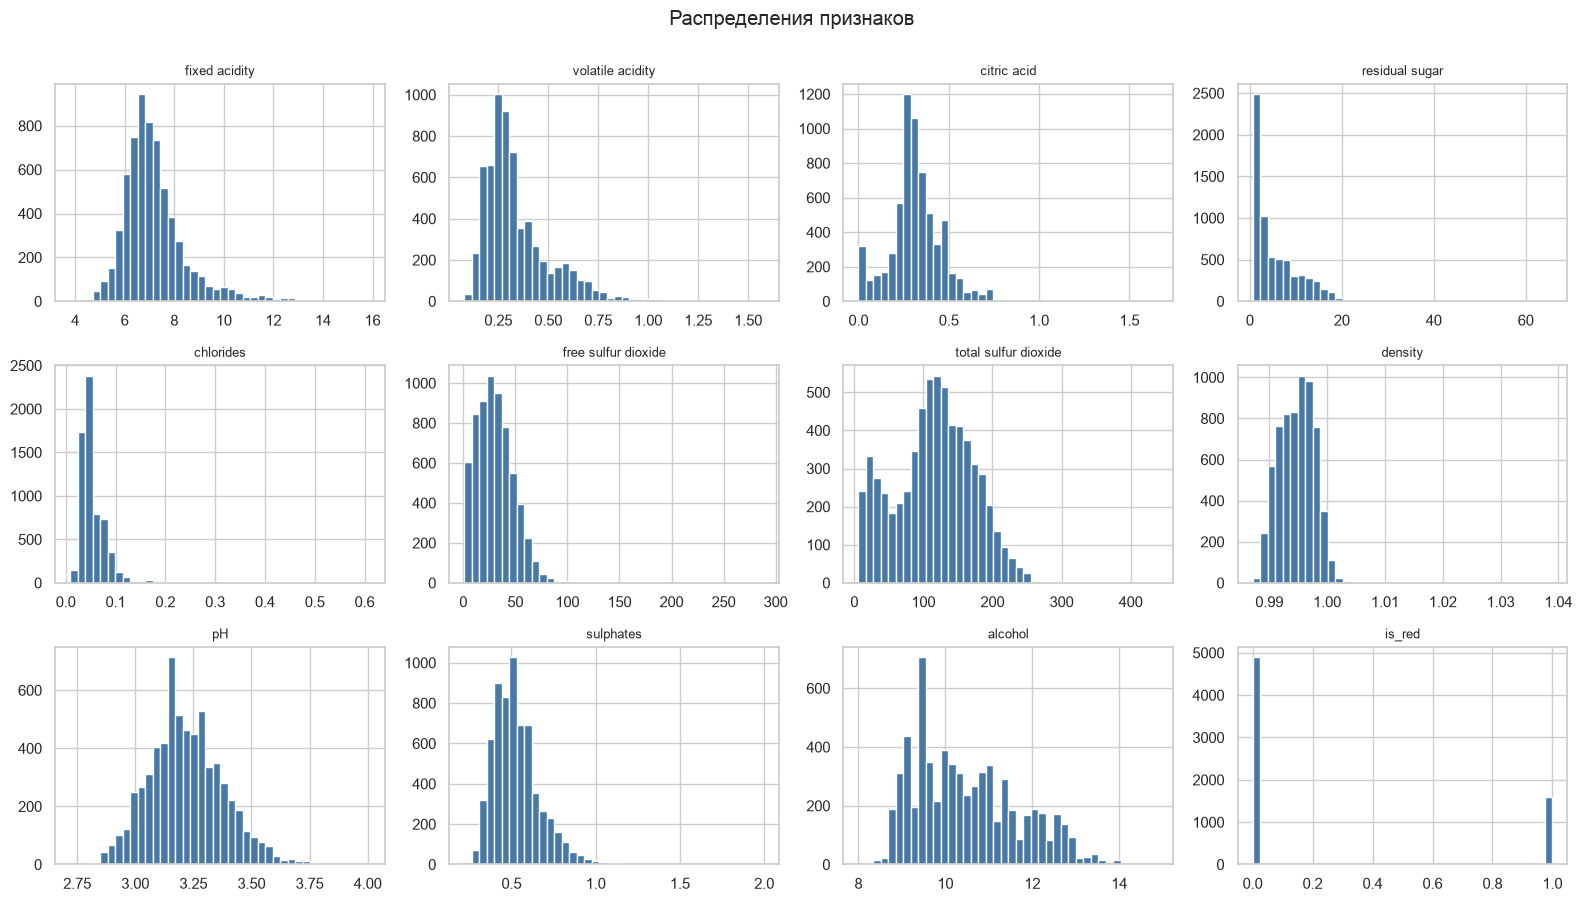

In [5]:
features = [c for c in df.columns if c not in ('quality', 'target')]
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, col in zip(axes.ravel(), features):
    ax.hist(df[col], bins=40, color='#4878a8', edgecolor='white')
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(features):]:
    ax.axis('off')
fig.suptitle('Распределения признаков', y=1.0)
fig.tight_layout()
save_fig('02_distributions.png')
plt.show()

**Рисунок 2 — Распределения признаков**

Спирт, кислотность и pH распределены почти симметрично, а остаточный сахар, хлориды и диоксид серы сильно скошены вправо.

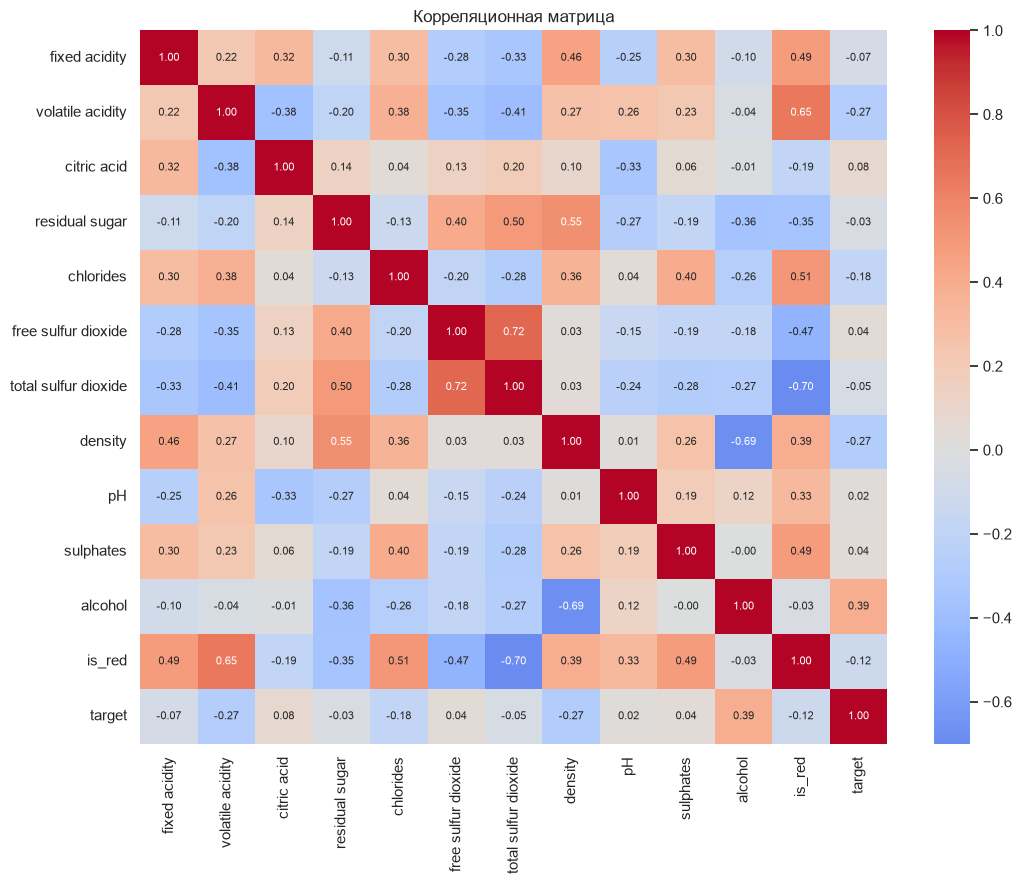

alcohol                 0.395
density                -0.269
volatile acidity       -0.267
chlorides              -0.182
is_red                 -0.117
citric acid             0.076
fixed acidity          -0.067
total sulfur dioxide   -0.048
free sulfur dioxide     0.045
sulphates               0.036
residual sugar         -0.032
pH                      0.019
Name: target, dtype: float64


In [6]:
corr = df[features + ['target']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 8}, ax=ax)
ax.set_title('Корреляционная матрица')
fig.tight_layout()
save_fig('03_correlation.png')
plt.show()

print(corr['target'].drop('target').sort_values(key=abs, ascending=False).round(3))

**Рисунок 3 — Корреляционная матрица признаков**

Сильнее всего с качеством связан спирт (r = 0,395), затем плотность (−0,269) и летучая кислотность (−0,267), у остальных признаков связь слабее 0,2.

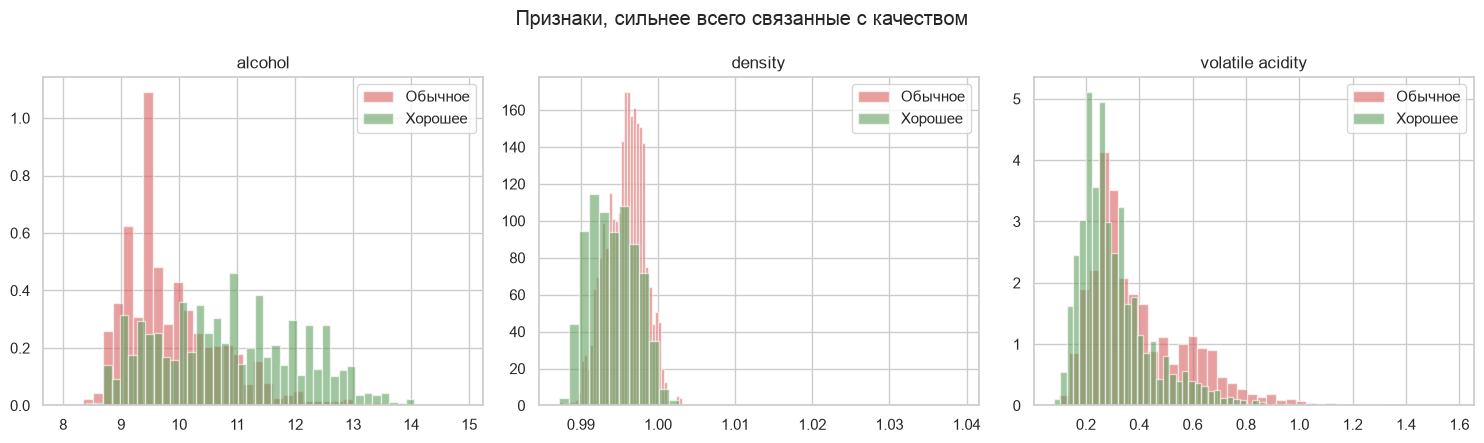

In [7]:
# три признака с наибольшей связью с целью
top3 = corr['target'].drop('target').abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, top3):
    for label, color, name in [(0, '#d95f5f', 'Обычное'), (1, '#5fa05f', 'Хорошее')]:
        ax.hist(df[df['target'] == label][col], bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(col)
    ax.legend()
fig.suptitle('Признаки, сильнее всего связанные с качеством')
fig.tight_layout()
save_fig('04_top_features.png')
plt.show()

**Рисунок 4 — Распределения трёх главных признаков по классам**

У хороших вин спирта больше, а летучей кислотности и плотности меньше, но распределения сильно пересекаются, поэтому по одному признаку классы не разделить.

## 3. Разбиение и масштабирование

Разбиение случайное 75 / 25 со стратификацией: записи независимы, временной структуры нет.
Логистическая регрессия, kNN и метод опорных векторов считают расстояния или линейные комбинации,
поэтому им нужны признаки одного масштаба. Среднее и отклонение считаю только по обучающей части.
Деревьям и лесу масштабирование не нужно.

In [8]:
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Обучение {len(X_train)}, тест {len(X_test)}')
print(f'Доля хороших вин: в обучении {y_train.mean():.3f}, в тесте {y_test.mean():.3f}')

Обучение 4872, тест 1625
Доля хороших вин: в обучении 0.633, в тесте 0.633


## 4. Пять классификаторов

1. **Логистическая регрессия** строит линейную границу между классами и даёт вероятность через сигмоиду.
2. **k ближайших соседей** относит вино к классу большинства среди 15 ближайших по измерениям вин.
3. **Дерево решений** задаёт вопросы вида «спирт больше 10,5?» и делит выборку на всё более чистые группы.
4. **Случайный лес** усредняет ответы 300 деревьев, каждое обучено на своей подвыборке.
5. **Метод опорных векторов** с ядром RBF строит нелинейную границу, максимизируя расстояние
   от неё до ближайших объектов каждого класса.

Каждый классификатор получает те данные, которые ему подходят: масштабированные для первых двух
и пятого, исходные для деревьев.

In [9]:
models = {
    'Логистическая регрессия': (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), True),
    'k ближайших соседей': (KNeighborsClassifier(n_neighbors=15), True),
    'Дерево решений': (DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE), False),
    'Случайный лес': (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), False),
    'Метод опорных векторов': (SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE), True),
}

fitted, proba = {}, {}
rows = []
for name, (model, needs_scale) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if needs_scale else (X_train, X_test)
    t0 = time.time()
    model.fit(Xtr, y_train)
    p = model.predict_proba(Xte)[:, 1]
    pred = (p > 0.5).astype(int)
    fitted[name], proba[name] = model, p
    rows.append({
        'Модель': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, p),
        'Время, с': time.time() - t0,
    })
    print(f'{name:25} обучен за {rows[-1]["Время, с"]:.1f} с')

results = pd.DataFrame(rows).set_index('Модель').sort_values('Accuracy', ascending=False)
results.round(4)

Логистическая регрессия   обучен за 0.0 с
k ближайших соседей       обучен за 0.0 с
Дерево решений            обучен за 0.0 с


Случайный лес             обучен за 0.4 с


/Users/f.arutyunyan/Documents/personal/mospolytech/mmo/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Метод опорных векторов    обучен за 1.6 с


,Accuracy,Precision,Recall,F1,ROC-AUC,"Время, с"
Модель,,,,,,
Случайный лес,0.8382,0.8507,0.9028,0.8760,0.8968,0.3901
Метод опорных векторов,0.7686,0.7837,0.8766,0.8275,0.8291,1.5513
k ближайших соседей,0.7514,0.7768,0.8523,0.8128,0.8159,0.0493
Дерево решений,0.7434,0.8030,0.7881,0.7955,0.7700,0.0238
Логистическая регрессия,0.7317,0.7585,0.8455,0.7996,0.7961,0.0117


## 5. Оценка и сравнение

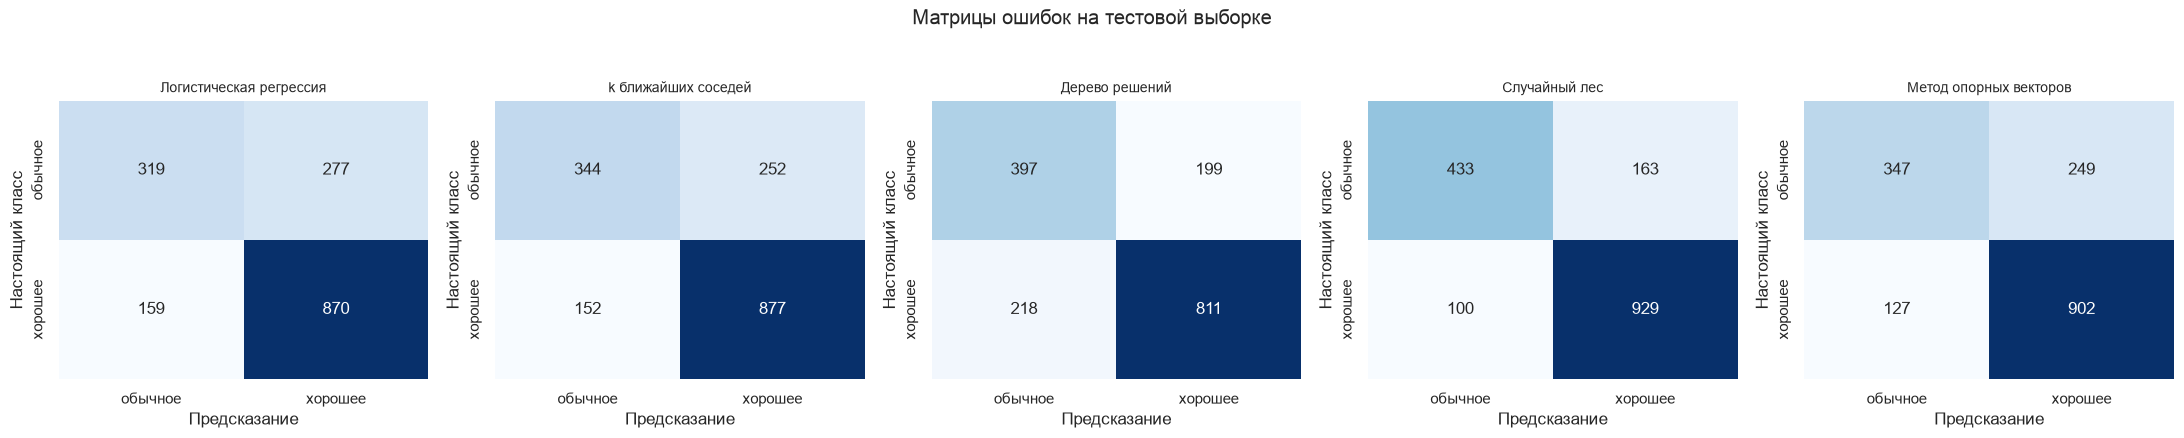

Логистическая регрессия   обычное названо хорошим:  277, хорошее названо обычным:  159
k ближайших соседей       обычное названо хорошим:  252, хорошее названо обычным:  152
Дерево решений            обычное названо хорошим:  199, хорошее названо обычным:  218
Случайный лес             обычное названо хорошим:  163, хорошее названо обычным:  100
Метод опорных векторов    обычное названо хорошим:  249, хорошее названо обычным:  127


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, (proba[name] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['обычное', 'хорошее'], yticklabels=['обычное', 'хорошее'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Настоящий класс')
fig.suptitle('Матрицы ошибок на тестовой выборке', y=1.04)
fig.tight_layout()
save_fig('05_confusion.png')
plt.show()

for name in models:
    tn, fp, fn, tp = confusion_matrix(y_test, (proba[name] > 0.5).astype(int)).ravel()
    print(f'{name:25} обычное названо хорошим: {fp:4}, хорошее названо обычным: {fn:4}')

**Рисунок 5 — Матрицы ошибок пяти классификаторов**

Случайный лес ошибается реже всех: 163 обычных вина названы хорошими и 100 хороших обычными против 277 и 159 у логистической регрессии.

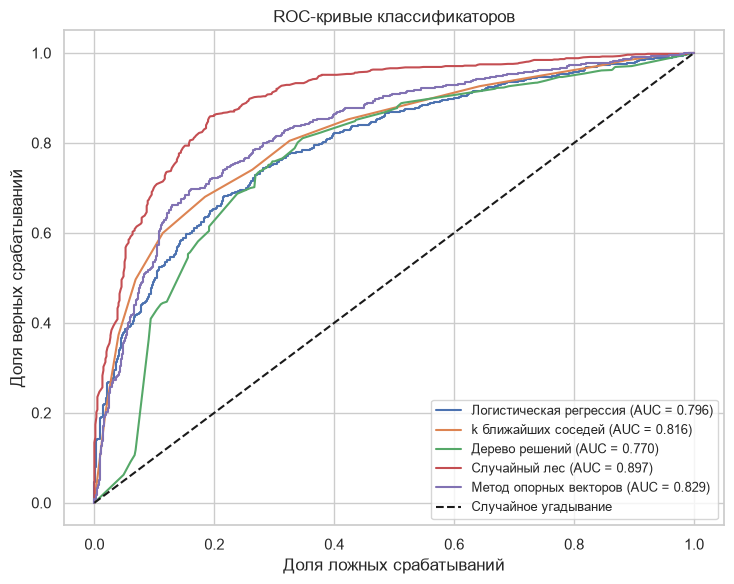

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba[name]):.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
ax.set_xlabel('Доля ложных срабатываний')
ax.set_ylabel('Доля верных срабатываний')
ax.set_title('ROC-кривые классификаторов')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
save_fig('06_roc.png')
plt.show()

**Рисунок 6 — ROC-кривые пяти классификаторов**

Кривая случайного леса идёт выше остальных (AUC 0,897), у метода опорных векторов 0,829, а у дерева решений всего 0,770.

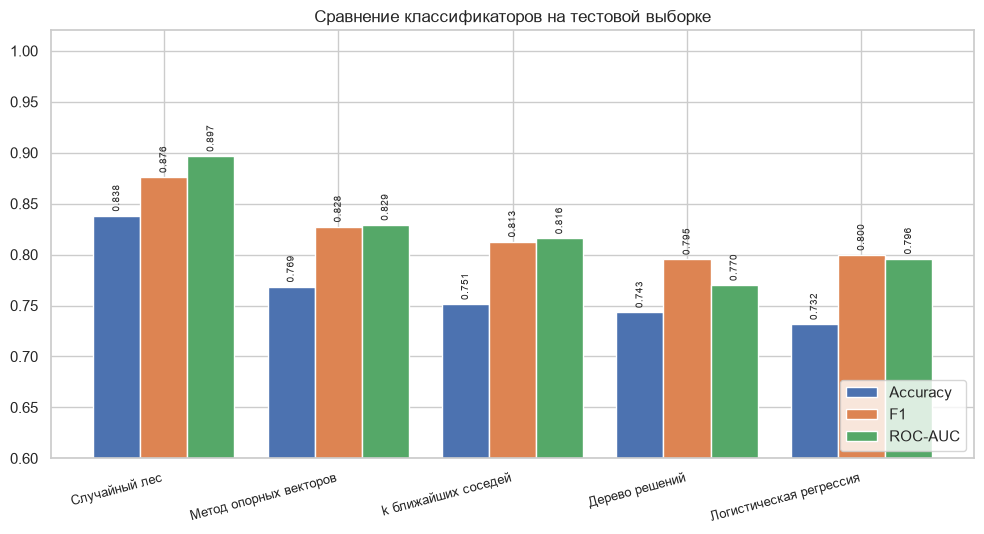

In [12]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = results[['Accuracy', 'F1', 'ROC-AUC']]
x = np.arange(len(plot_df))
width = 0.27
for i, metric in enumerate(plot_df.columns):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric)
    ax.bar_label(bars, fmt='%.3f', fontsize=7, rotation=90, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.6, 1.02)
ax.set_title('Сравнение классификаторов на тестовой выборке')
ax.legend(loc='lower right')
fig.tight_layout()
save_fig('07_comparison.png')
plt.show()

**Рисунок 7 — Сравнение классификаторов по метрикам**

Случайный лес выигрывает по всем трём метрикам (accuracy 0,838, F1 0,876, ROC-AUC 0,897), худшая модель логистическая регрессия (0,732).

/Users/f.arutyunyan/Documents/personal/mospolytech/mmo/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/mmo/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/f.arutyunyan/Documents/personal/mospolytech/mmo/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/f.arutyunyan/Documents/pers

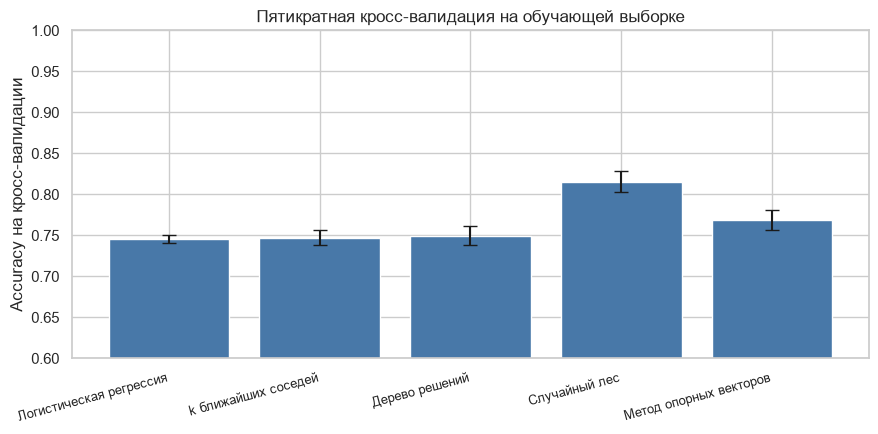

,CV accuracy,Разброс
Модель,,
Логистическая регрессия,0.7457,0.0053
k ближайших соседей,0.7473,0.0088
Дерево решений,0.7498,0.0121
Случайный лес,0.8153,0.0128
Метод опорных векторов,0.7687,0.0121


In [13]:
# устойчивость результата: пятикратная кросс-валидация на обучающей выборке
cv_rows = []
for name, (model, needs_scale) in models.items():
    Xtr = X_train_s if needs_scale else X_train
    scores = cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_rows.append({'Модель': name, 'CV accuracy': scores.mean(), 'Разброс': scores.std()})
cv_df = pd.DataFrame(cv_rows).set_index('Модель')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(cv_df.index, cv_df['CV accuracy'], yerr=cv_df['Разброс'], capsize=5, color='#4878a8')
ax.set_xticks(range(len(cv_df)))
ax.set_xticklabels(cv_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('Accuracy на кросс-валидации')
ax.set_title('Пятикратная кросс-валидация на обучающей выборке')
fig.tight_layout()
save_fig('08_crossval.png')
plt.show()

cv_df.round(4)

**Рисунок 8 — Accuracy на пятикратной кросс-валидации**

На кросс-валидации порядок тот же: лес 0,815 ± 0,013, метод опорных векторов 0,769, остальные около 0,75, значит разрыв не случайность одного разбиения.

Лучшая модель: Случайный лес


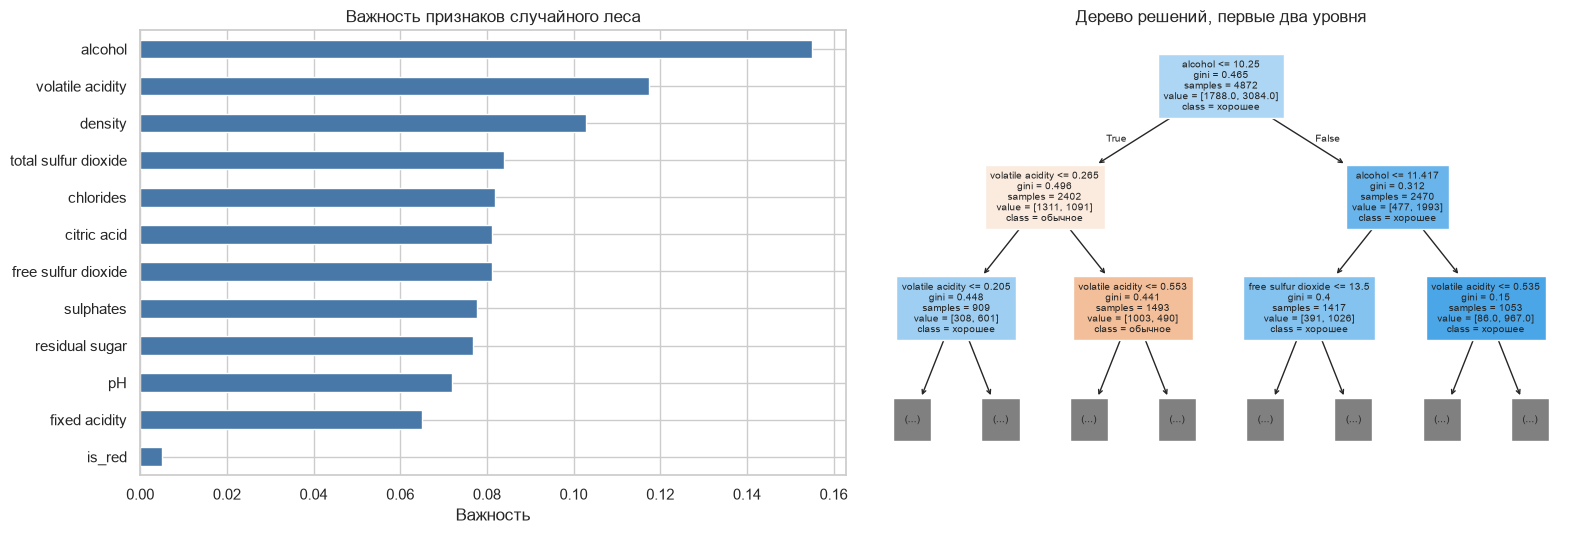

alcohol                 0.155
volatile acidity        0.117
density                 0.103
total sulfur dioxide    0.084
chlorides               0.082
dtype: float64


In [14]:
# что важно лучшей модели и как выглядит дерево
best_name = results.index[0]
print('Лучшая модель:', best_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
importances = pd.Series(fitted['Случайный лес'].feature_importances_, index=features).sort_values()
importances.plot.barh(ax=axes[0], color='#4878a8')
axes[0].set_title('Важность признаков случайного леса')
axes[0].set_xlabel('Важность')

plot_tree(fitted['Дерево решений'], max_depth=2, feature_names=features,
          class_names=['обычное', 'хорошее'], filled=True, fontsize=7, ax=axes[1])
axes[1].set_title('Дерево решений, первые два уровня')
fig.tight_layout()
save_fig('09_importance_tree.png')
plt.show()

print(importances.sort_values(ascending=False).round(3).head(5))

**Рисунок 9 — Важность признаков случайного леса и верх дерева решений**

Лес опирается на спирт (0,155), летучую кислотность (0,117) и плотность (0,103), и дерево решений первым вопросом тоже делит вина по спирту (порог 10,25 %).

In [15]:
print(classification_report(y_test, (proba[best_name] > 0.5).astype(int),
                            target_names=['обычное', 'хорошее'], digits=4))

              precision    recall  f1-score   support

     обычное     0.8124    0.7265    0.7671       596
     хорошее     0.8507    0.9028    0.8760      1029

    accuracy                         0.8382      1625
   macro avg     0.8316    0.8147    0.8215      1625
weighted avg     0.8367    0.8382    0.8360      1625



## 6. Выводы

1. **Данные.** Wine Quality из UCI: 6497 вин, 11 лабораторных измерений и признак цвета.
   Цель бинарная: оценка дегустаторов не ниже 6. Хороших вин 63,3 %, обычных 36,7 %.

2. **Лучший классификатор: случайный лес.** На тесте из 1625 вин accuracy 0,8382, precision 0,8507,
   recall 0,9028, F1 0,8760, ROC-AUC 0,8968. На кросс-валидации 0,8153 ± 0,0128.

3. **Порядок моделей:** лес 0,838, метод опорных векторов 0,769, k ближайших соседей 0,751,
   дерево решений 0,743, логистическая регрессия 0,732. Лес выигрывает, потому что качество зависит
   от признаков нелинейно и через их сочетания: высокое содержание спирта помогает только при низкой
   летучей кислотности. Линейная модель такую зависимость описать не может, а одно дерево ловит её
   неустойчиво, сто деревьев усредняют эту неустойчивость.

4. **Метод опорных векторов** с ядром RBF тоже строит нелинейную границу и обгоняет линейную модель
   на 3,7 процентного пункта, но проигрывает лесу и обучается дольше всех (1,55 с против 0,39 с у леса).

5. **Масштабирование.** Логистической регрессии, kNN и методу опорных векторов признаки
   стандартизированы: они считают расстояния или линейные комбинации, а диоксид серы измеряется
   сотнями при кислотности около единицы. Деревьям масштаб не важен, они сравнивают признак с порогом.

6. **Ошибки.** Все модели чаще называют обычное вино хорошим, чем наоборот: у леса 163 против 100.
   Класс хороших вин больше (63 %), поэтому при сомнении модель склоняется к нему.

7. **Главные признаки:** спирт (важность 0,155), летучая кислотность (0,117) и плотность (0,103).
   Цвет вина почти не влияет (0,005). Дерево решений первым вопросом делит вина по спирту.

8. **Что улучшило бы результат:** подбор гиперпараметров леса, градиентный бустинг,
   учёт дисбаланса классов через веса, отдельные модели для красного и белого вина.